# Prepare the dataset

In [ ]:
import kagglehub
import shutil

# Download latest version
path = kagglehub.dataset_download("allahhitler/ocr-synthetic-dataset")

print("Path to dataset files:", path)

shutil.copytree(path, "/content/data", dirs_exist_ok=True)

Using Colab cache for faster access to the 'ocr-synthetic-dataset' dataset.
Path to dataset files: /kaggle/input/ocr-synthetic-dataset


'/content/data'

# Split the data

In [ ]:
import os
from pathlib import Path

%cd data
def split_dataset(image_dir, labels_file, train_ratio=0.8, val_ratio=0.1):
    """
    Split dataset into training, validation, and testing sets.

    Args:
        image_dir (str): Path to directory containing images
        labels_file (str): Path to labels.txt file
        train_ratio (float): Ratio of training data (default: 0.8 = 80%)
        val_ratio (float): Ratio of validation data (default: 0.1 = 10%)
    """

    # Read labels file
    with open(labels_file, 'r') as f:
        lines = f.readlines()

    # Parse labels
    image_labels = {}
    for line in lines:
        if line.strip():
            filename, label = line.strip().split(' ', 1)
            image_labels[filename] = label

    # Get sorted list of image files
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.jpg')])
    total_images = len(image_files)

    # Calculate split points
    train_end = int(total_images * train_ratio)
    val_end = int(total_images * (train_ratio + val_ratio))

    # Create directories
    base_dirs = {
        "train": Path("train"),
        "val": Path("val"),
        "test": Path("test")
    }

    for d in base_dirs.values():
        (d / "images").mkdir(parents=True, exist_ok=True)

    # Initialize label lists
    label_files = {
        "train": [],
        "val": [],
        "test": []
    }

    # Split the dataset
    for i, image_file in enumerate(image_files):
        src_path = Path(image_dir) / image_file

        if i < train_end:
            split = "train"
        elif i < val_end:
            split = "val"
        else:
            split = "test"

        dest_path = base_dirs[split] / "images" / image_file
        shutil.copy2(src_path, dest_path)
        label_files[split].append(f"{image_file} {image_labels[image_file]}")

    # Write label files
    for split, lines in label_files.items():
        with open(base_dirs[split] / "labels.txt", "w") as f:
            f.write("\n".join(lines))

    # Print summary
    print("Dataset split completed!")
    print(f"Total images: {total_images}")
    print(f"Training set: {train_end} images ({train_ratio:.0%})")
    print(f"Validation set: {val_end - train_end} images ({val_ratio:.0%})")
    print(f"Testing set: {total_images - val_end} images ({1 - train_ratio - val_ratio:.0%})")
    print("\nDirectory structure:")
    for split in ["train", "val", "test"]:
        print(f"{split}/")
        print(f"├── labels.txt")
        print(f"└── images/")
    print("\nAll done!")


# Configuration
IMAGE_DIR = "images"       # Directory containing your images
LABELS_FILE = "labels.txt" # Path to labels.txt
TRAIN_RATIO = 0.8          # 80% for training
VAL_RATIO = 0.1            # 10% for validation (remaining 10% for testing)

split_dataset(IMAGE_DIR, LABELS_FILE, TRAIN_RATIO, VAL_RATIO)

%cd ..

!mkdir checkpoints/

/content/data
Dataset split completed!
Total images: 100000
Training set: 80000 images (80%)
Validation set: 10000 images (10%)
Testing set: 10000 images (10%)

Directory structure:
train/
├── labels.txt
└── images/
val/
├── labels.txt
└── images/
test/
├── labels.txt
└── images/

All done!
/content


# Configurations

In [1]:
# You are welcome to modify the configs in the way you like

config = {
    'data_dir': '/content/data',
    'img_width': 100,
    'img_height': 32,
    'map_to_seq_hidden': 64,
    'rnn_hidden': 256,
    'leaky_relu': False,
    'max_label_len': 32,
}

train_config = {
    'epochs': 4,
    'train_batch_size': 32,
    'eval_batch_size': 256,
    'lr': 0.0005,
    'show_interval': 10,
    'valid_interval': 500,
    'save_interval': 500,
    'cpu_workers': 4,
    'valid_max_iter': 100,
    'decode_method': 'beam_search',
    'beam_size': 10,
    'checkpoints_dir': 'checkpoints',
    # New checkpoint-related settings
    'max_checkpoints_to_keep': 3,
    'resume_training': True,           # Auto-resume from latest checkpoint
    'checkpoint_path': None,           # Specific checkpoint to load (optional)
    'save_every_epoch': False,         # Save at end of each epoch
    'save_h5_weights': True,           # Also save H5 for compatibility
}
train_config.update(config)

evaluate_config = {
    'eval_batch_size': 256,
    'cpu_workers': 4,
    'decode_method': 'beam_search',
    'beam_size': 10,
    # Updated checkpoint loading for evaluation
    'checkpoint_path': 'checkpoints',  # Can be specific file or directory
    'resume_training': False,           # Set to False for evaluation
}
evaluate_config.update(config)

In [2]:
config

{'data_dir': '/content/data',
 'img_width': 100,
 'img_height': 32,
 'map_to_seq_hidden': 64,
 'rnn_hidden': 256,
 'leaky_relu': False,
 'max_label_len': 32}

In [3]:
train_config

{'epochs': 4,
 'train_batch_size': 32,
 'eval_batch_size': 256,
 'lr': 0.0005,
 'show_interval': 10,
 'valid_interval': 500,
 'save_interval': 500,
 'cpu_workers': 4,
 'valid_max_iter': 100,
 'decode_method': 'beam_search',
 'beam_size': 10,
 'checkpoints_dir': 'checkpoints',
 'max_checkpoints_to_keep': 3,
 'resume_training': True,
 'checkpoint_path': None,
 'save_every_epoch': False,
 'save_h5_weights': True,
 'data_dir': '/content/data',
 'img_width': 100,
 'img_height': 32,
 'map_to_seq_hidden': 64,
 'rnn_hidden': 256,
 'leaky_relu': False,
 'max_label_len': 32}

In [4]:
evaluate_config

{'eval_batch_size': 256,
 'cpu_workers': 4,
 'decode_method': 'beam_search',
 'beam_size': 10,
 'checkpoint_path': 'checkpoints',
 'resume_training': False,
 'data_dir': '/content/data',
 'img_width': 100,
 'img_height': 32,
 'map_to_seq_hidden': 64,
 'rnn_hidden': 256,
 'leaky_relu': False,
 'max_label_len': 32}

# `Dataset` class

In [5]:
import os
import tensorflow as tf
import numpy as np
from PIL import Image
from enum import Enum
from typing import Optional, List, Tuple, Union

class DatasetMode(Enum):
    TRAIN = 'train'
    VAL = 'val'
    TEST = 'test'

class Synth90kDataset:
    # TODO: define `CHARS`, `CHAR2LABEL` and `LABEL2CHAR`
    CHARS = "".join(chr(n) for n in range(48, 58)) + \
            "".join(chr(l) for l in range(97, 123)) + \
            "".join(chr(u) for u in range(65, 91))

    CHAR2LABEL = {k:v for v, k in enumerate(CHARS, start=1)}

    LABEL2CHAR = {k:v for k, v in enumerate(CHARS, start=1)}

    def __init__(
        self,
        root_dir: Optional[str] = None,
        mode: Optional[DatasetMode] = None,
        paths: Optional[List[str]] = None,
        img_height: int = 32,
        img_width: int = 100
    ):
        if root_dir and mode and not paths:
            self.paths, self.texts = self._load_from_raw_files(root_dir, mode)
        elif not root_dir and not mode and paths:
            self.paths = paths
            self.texts = None

        self.img_height = img_height
        self.img_width = img_width

    def _load_from_raw_files(self, root_dir: str, mode: DatasetMode) -> Tuple[List[str], List[str]]:
        """
        Load image file paths and their corresponding text labels from label files.

        This method reads a label file containing filename–text pairs, constructs
        the full image paths, and extracts the associated text labels. Each line
        in the label file must follow the format:

            filename text_label

        Args:
            root_dir (str): Root directory where the dataset is stored.
            mode (DatasetMode): Dataset split to load (e.g., TRAIN, VAL, TEST).

        Returns:
            tuple[list[str], list[str]]:
                - paths: List of full paths to image files in the format
                  "data/{mode}/images/{filename}".
                - texts: List of text labels corresponding to each image path.

        Example:
            If root_dir = "/dataset", mode = TRAIN, and the file
            "/dataset/train/labels.txt" contains:
                img1.jpg hello
                img2.jpg world

            The method will return:
                paths = ["data/train/images/img1.jpg", "data/train/images/img2.jpg"]
                texts = ["hello", "world"]
        """

        paths_file = f"{mode.value}/labels.txt"
        paths: List[str] = []
        texts: List[str] = []

        # Read the labels file and parse each line
        with open(os.path.join(root_dir, paths_file), 'r') as fr:
            for line in fr.readlines():
                # TODO: path contains filenames and text are the labels
                s = line.split()
                paths.append(f"{root_dir}/{mode.value}/images/" + s[0])
                texts.append(s[1])

        return paths, texts

    def __len__(self) -> int:
        return len(self.paths)

    def create_tf_dataset(self, batch_size: int = 32, training: bool = True) -> tf.data.Dataset:
      """
      Create a TensorFlow Dataset for efficient data loading and preprocessing.

      This method generates a tf.data.Dataset pipeline that can be used for training
      or validation. It handles both cases with and without text labels, applying
      appropriate batching and preprocessing optimizations.
      """
      def generator():
          """
          Generator function that yields individual preprocessed samples.

          Yields:
              tuple or ndarray: Single processed sample from _process_single_item
          """
          for i in range(len(self.paths)):
              yield self._process_single_item(i)

      # TODO: Define output signature using tf.TensorSpec based on whether text labels are available
      if self.texts:
        spec = (tf.TensorSpec(shape=(self.img_height, self.img_width, 1), dtype=tf.float32),
                tf.TensorSpec(shape=(None, ), dtype=tf.int32),
                tf.TensorSpec(shape=(), dtype=tf.int32)
        )
      else:
        spec = tf.TensorSpec(shape=(self.img_height, self.img_width), dtype=tf.float32)


      # TODO: Create TensorFlow dataset from generator using tf.data.Dataset.from_generator()
      dataset = tf.data.Dataset.from_generator(generator, output_signature=spec)

      # Apply appropriate batching strategy based on text presence
      if self.texts:
          # TODO: Call dataset.padded_batch for variable-length text sequences
          dataset = dataset.padded_batch(batch_size=batch_size,
                                         drop_remainder=True,
                                         padded_shapes=((self.img_height, self.img_width, 1), config['max_label_len'], ()),
                                         padding_values=(0.0, 0, 0))

          # Apply training-specific optimizations
          if training:
              # Prefetch batches for improved pipeline performance
              dataset = dataset.prefetch(tf.data.AUTOTUNE)
      else:
          # Simple batching for datasets without text labels
          dataset = dataset.batch(batch_size)

      return dataset

    def _process_single_item(self, index: int) -> Union[Tuple[np.ndarray, np.ndarray, int], np.ndarray]:
      """
      Process a single data item by loading, preprocessing image and text.

      This method handles the complete preprocessing pipeline for a single data sample,
      including image loading, resizing, normalization, and text label conversion.
      It includes error handling for corrupted images and recursive fallback.
      """
      path = self.paths[index]

      try:
          # Load image and convert to grayscale
          image = Image.open(path).convert('L')
      except IOError:
          # Handle corrupted images by recursively trying the next sample
          print('Corrupted image for %d' % index)
          return self._process_single_item((index + 1) % len(self.paths))

      # TODO: Expect image with shape (img_height, img_width, 1) and pixel values in [-1, 1] (use bilinear interpolation to resize)
      image = image.resize((self.img_width, self.img_height), Image.Resampling.BILINEAR)
      image = np.array(image).astype('float32')
      image = image / 255 * 2 - 1
      image = image.reshape((*image.shape, 1))

      # Process text labels if available
      if self.texts:
          text = self.texts[index]
          # TODO: Expect target as a list of integer labels mapped from each character in text (target_length is the length of the target list)
          target = [self.CHAR2LABEL[c] for c in text]
          target_length = len(target)

          # Return image with text labels and sequence length
          return image, np.array(target, dtype=np.int32), target_length
      else:
          # Return only the preprocessed image when no text labels are available
          return image


2025-11-10 21:15:39.654029: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 21:15:39.710433: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 21:15:41.038283: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [6]:
# For checking
Synth90kDataset(root_dir="/content/data",
                mode=DatasetMode.TRAIN,
                img_height=config["img_height"],
                img_width=config["img_width"]).create_tf_dataset(batch_size=32).element_spec

I0000 00:00:1762780544.101120  401498 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2153 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


(TensorSpec(shape=(32, 32, 100, 1), dtype=tf.float32, name=None),
 TensorSpec(shape=(32, 32), dtype=tf.int32, name=None),
 TensorSpec(shape=(32,), dtype=tf.int32, name=None))

# `CRNN` Class

##Q1
Given:
1. f = width of kernel = height of kernel = 3
2. C = # of channels of the input = 256
3. K = # of filters = 512

\# of trainable parameters for Conv2D in layer 4 \
= (f \* f \* C + 1) * K \
= (3 \* 3 \* 256 + 1) * 512 \
= 1180160

## Q2

For the height of the output shape, given:
1. h = height of input = H/16
2. f = width of kernel = height of kernel = 2
3. p = padding = 'valid' = 0
4. s = stride = 1

Height of the output shape \
= floor((h + 2p - f) / s + 1) \
= floor((H/16 + 0 - 2) / 1 + 1) \
= floor(H/16 - 2 + 1) \
= floor(H/16 - 1) \
= H/16 - 1, where H/16 is an integer since it is the exact height of the input

---

For the width of the output shape, given:
1. w = width of input = W/4
2. f = width of kernel = height of kernel = 2
3. p = padding = 'valid' = 0
4. s = stride = 1

Width of the output shape \
= floor((w + 2p - f) / s + 1) \
= floor((W/4 + 0 - 2) / 1 + 1) \
= floor(W/4 - 2 + 1) \
= floor(W/4 - 1) \
= W/4 - 1, where W/4 is an integer since it is the exact width of the input

---

Depth of the output shape depends on # of filters assigned, which is 512.

---

Therefore, the output shape of layer 6 = (H/16 - 1, W/4 - 1, 512)

## Q3

The CRNN model is to perform OCR on English text images. English words have characters horizontally ordered in the temporal space such that the frequency of each character has dependency on the surrounding characters.

Moreover, as the image is not very wide (~25px at layer 3 and 5), doing further subsampling on temporal space may loss critical information. Particularly, if 1 pooling operation subsamples on 2 different characters, the word extracted will be totally different, and the dependency may be broken.

---

On the other hand, each single character spanning the height of the image has spatial information about its shape, but they do not have strong dependency among one another.

Therefore, doing subsampling can increase the robustness on recognizing characters in different image conditions.

---

Based on this situation and the architecture of the CRNN model, pooling against height but not width (i.e. pool & stride = (2, 1)) can keep the dependency of characters whilst increase robustness of detecting each characters.

In [7]:
from tensorflow.keras import layers

class CRNN(tf.keras.Model):
    """
    Convolutional Recurrent Neural Network (CRNN) for sequence recognition.

    This model combines CNN feature extraction with RNN sequence modeling,
    commonly used for tasks like text recognition in images. The architecture
    follows the CRNN design with CNN backbone followed by bidirectional LSTMs.

    Args:
        img_channel (int): Number of channels in input images (1 for grayscale, 3 for RGB)
        img_height (int): Height of input images (must be divisible by 16)
        img_width (int): Width of input images (must be divisible by 4)
        num_class (int): Number of output classes (typically characters + 1 for blank)
        map_to_seq_hidden (int, optional): Hidden units in the mapping layer between CNN and RNN.
                                          Defaults to 64.
        rnn_hidden (int, optional): Number of hidden units in each LSTM layer. Defaults to 256.
        leaky_relu (bool, optional): Whether to use LeakyReLU instead of ReLU. Defaults to False.
        **kwargs: Additional keyword arguments passed to the parent class.

    Architecture:
        - CNN Backbone: 7 convolutional layers with pooling for feature extraction
        - Map to Sequence: Dense layer to transform CNN features to sequence format
        - RNN: Two bidirectional LSTM layers for sequence modeling
        - Output: Dense layer for logits

    Input Shape:
        (batch_size, img_height, img_width, img_channel)

    Output Shape:
        (width, batch_size, num_class) - Transposed for CTC loss compatibility

    Note:
        - Input image dimensions must satisfy: height % 16 == 0 and width % 4 == 0
        - Uses bidirectional LSTMs for better context understanding
    """

    def __init__(self, img_channel, img_height, img_width, num_class,
                 map_to_seq_hidden=64, rnn_hidden=256, leaky_relu=False, **kwargs):
        super().__init__(**kwargs)

        # Store model configuration parameters
        self.img_channel = img_channel
        self.img_height = img_height
        self.img_width = img_width
        self.num_class = num_class
        self.map_to_seq_hidden = map_to_seq_hidden
        self.rnn_hidden = rnn_hidden
        self.leaky_relu = leaky_relu

        # TODO: Build CNN backbone for feature extraction
        self.cnn = self._build_cnn_backbone(self.img_channel, self.leaky_relu)
        # TODO: Dense layer to map CNN features to sequence format for RNN
        self.dense1 = layers.Dense(self.map_to_seq_hidden)
        # TODO: Two bidirectional LSTM layers for sequence modeling
        self.bi1 = layers.Bidirectional(layers.LSTM(self.rnn_hidden, return_sequences=True))
        self.bi2 = layers.Bidirectional(layers.LSTM(self.rnn_hidden, return_sequences=True))
        # TODO: Output layer for class probability prediction
        self.dense2 = layers.Dense(self.num_class)

    def _build_cnn_backbone(self, img_channel, leaky_relu):
        """
        Build the CNN backbone for feature extraction.

        The CNN consists of 7 convolutional layers with pooling and batch normalization.
        It progressively reduces spatial dimensions while increasing feature depth.

        Args:
            img_channel (int): Number of input image channels
            leaky_relu (bool): Whether to use LeakyReLU activation

        Returns:
            tf.keras.Sequential: CNN backbone model

        Architecture Details:
            - Layers 0-1: 64 and 128 filters with 2x2 max pooling
            - Layers 2-3: 256 filters with special (2,1) pooling
            - Layers 4-5: 512 filters with batch normalization and (2,1) pooling
            - Layer 6: 512 filters with valid padding (reduces width by 1)

        Note:
            - Input height must be divisible by 16 due to pooling strides
            - Input width must be divisible by 4 due to pooling strides
        """
        # Validate input dimensions meet architectural requirements
        assert self.img_height % 16 == 0
        assert self.img_width % 4 == 0

        model = tf.keras.Sequential()

        # TODO: Define input shape
        input_shape = (self.img_height, self.img_width, img_channel)

        # TODO: Layer 0: 64 filters, 3x3 convolution, ReLU/LeakyReLU, 2x2 max pooling
        model.add(layers.Conv2D(64, 3, 1, 'same', input_shape=input_shape))
        model.add(layers.LeakyReLU(0.2) if leaky_relu else layers.ReLU())
        model.add(layers.MaxPool2D((2, 2), (2, 2)))

        # TODO: Layer 1: 128 filters, 3x3 convolution, ReLU/LeakyReLU, 2x2 max pooling
        model.add(layers.Conv2D(128, 3, 1, 'same'))
        model.add(layers.LeakyReLU(0.2) if leaky_relu else layers.ReLU())
        model.add(layers.MaxPool2D((2, 2), (2, 2)))

        # TODO: Layer 2: 256 filters, 3x3 convolution, ReLU/LeakyReLU (no pooling)
        model.add(layers.Conv2D(256, 3, 1, 'same'))
        model.add(layers.LeakyReLU(0.2) if leaky_relu else layers.ReLU())

        # TODO: Layer 3: 256 filters, 3x3 convolution, ReLU/LeakyReLU, (2,1) max pooling
        model.add(layers.Conv2D(256, 3, 1, 'same'))
        model.add(layers.LeakyReLU(0.2) if leaky_relu else layers.ReLU())
        model.add(layers.MaxPool2D((2, 1), (2, 1)))

        # TODO: Layer 4: 512 filters with batch normalization, ReLU/LeakyReLU
        model.add(layers.Conv2D(512, 3, 1, 'same'))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU(0.2) if leaky_relu else layers.ReLU())

        # TODO: Layer 5: 512 filters with batch normalization, ReLU/LeakyReLU, (2,1) max pooling
        model.add(layers.Conv2D(512, 3, 1, 'same'))
        model.add(layers.BatchNormalization())
        model.add(layers.LeakyReLU(0.2) if leaky_relu else layers.ReLU())
        model.add(layers.MaxPool2D((2, 1), (2, 1)))

        # TODO: Layer 6: 512 filters, 2x2 convolution with valid padding, ReLU/LeakyReLU
        model.add(layers.Conv2D(512, 2, 1, 'valid'))
        model.add(layers.LeakyReLU(0.2) if leaky_relu else layers.ReLU())

        return model

    def build(self, input_shape):
        """
        Build the model by explicitly constructing all layers.

        This method ensures all layers are properly built with the correct
        input shapes before the first forward pass.

        Args:
            input_shape: Shape of the input tensor
        """
        # Explicitly build each component to ensure proper weight initialization
        super(CRNN, self).build(input_shape)

    def call(self, images, training=False):
        """
        Forward pass of the CRNN model.

        Processes input images through CNN feature extraction, sequence mapping,
        RNN sequence modeling, and final classification layers.

        Args:
            images (tf.Tensor): Input image tensor of shape
                               (batch_size, height, width, channels)
            training (bool, optional): Whether the model is in training mode.
                                      Defaults to False.

        Returns:
            tf.Tensor: Output tensor of shape (width, batch_size, num_class)
                       Transposed for compatibility with CTC loss functions

        Processing Steps:
            1. CNN feature extraction
            2. Map to sequence with dense layer
            3. Process through two bidirectional LSTM layers
            4. Apply dense layer for classification

        Note: You may need to reshape to match dimension
        """
        # TODO: CNN feature extraction: (batch, height, width, channels)
        output = self.cnn(images, training=training)
        output = layers.Reshape((self.img_width // 4 - 1, -1))(output)

        # TODO: Map CNN features to sequence format
        output = self.dense1(output)

        # TODO: Process through bidirectional LSTM layers
        output = self.bi1(output)
        output = self.bi2(output)

        # TODO: Final classification layer: (batch, width, num_class)
        output = self.dense2(output)
        #output = tf.transpose(output, (1, 0, 2))

        return output


In [8]:

crnn = CRNN(1, config["img_height"], config["img_width"], len(Synth90kDataset.LABEL2CHAR) + 1,
                map_to_seq_hidden=config['map_to_seq_hidden'],
                rnn_hidden=config['rnn_hidden'],
                leaky_relu=config['leaky_relu'])
crnn.build(input_shape=(None, config["img_height"], config["img_width"], 1))
crnn.summary()

crnn.cnn.summary()

/usr/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "crnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 1, 24, 512)     │     5,552,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,552,896 (21.18 MB)

 Trainable params: 5,550,848 (21.17 MB)

...

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 100, 64)    │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 100, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 25, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 25, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 25, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 25, 256)     │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 8, 25, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 25, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 4, 25, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 25, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 4, 25, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 25, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 25, 512)     │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 4, 25, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 25, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 1, 24, 512)     │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 1, 24, 512)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,552,896 (21.18 MB)

 Trainable params: 5,550,848 (21.17 MB)

 Non-trainable params: 2,048 (8.00 KB)

## Q4

Due to the feature reshape applied on the output of CNN,

\# of features after reshape \
= (H / 16 - 1) \* 512 \
= H \* 32 - 512 \
= 32 \* 32 - 512, given H = 32 \
= 512

---

Ratio of the original image width to the sequence length (r) \
= W : W / 4 \
= 4 : 1

---

Each column of features has 512 entries, corresponding to 512 sets of convolved and subsampled values against the height dimension.

Additionally considering the ratio (r), each position of the sequence corresponds to 4 complete columns of pixels in the original image.

---

As the last dense layer outputs logits for character classification, this approach is effective since each sequence position carries sufficient yet appropriate amount of information. If the ratio (r) is too small, it would be difficult for the RNN layer to infer the character with very few features to do further dependency inference. If the ratio (r) is too large, there would be too few characters for RNN to infer the dependency.

## Q5

As the 2 bidirectional LSTMs are stacked serially, it can be expected that the first layer learns the shorter dependency among characters, and the second layer learns the longer dependency among small sets of characters (e.g. prefix / suffix) to form a word.

In general, stacking more layers of LSTM can let the model learning more and deeper hierarchical features (e.g. character -> prefix / suffix -> word). Therefore, the model is more robust on complex inputs. However, more layers may lead to overfitting and more computational time. Moreover, more layers may cause the vanishing / exploding gradient problem during training.

# `CTCLoss` Class

In [9]:
class CTCLoss(tf.keras.losses.Loss):
    """
    Connectionist Temporal Classification (CTC) Loss for sequence recognition tasks.

    This loss function is designed for sequence-to-sequence tasks where the alignment
    between inputs and labels is unknown, such as speech recognition or handwritten
    text recognition. It computes the negative log probability of the correct sequence.

    The CTC loss handles variable-length sequences by considering all possible alignments
    between the input sequence (model predictions) and the target sequence (labels).

    Inherits from:
        tf.keras.losses.Loss

    Typical Use Cases:
        - Optical Character Recognition (OCR)
        - Speech Recognition
        - Handwriting Recognition
        - Any sequence labeling task with unaligned sequences

    Note:
        - Assumes blank index is 0 (standard for CTC)
        - Handles variable-length sequences automatically
        - Uses logits (unnormalized scores) rather than probabilities
        - Computes mean loss across the batch
    """

    def call(self, y_true, y_pred):
        """
        Compute the CTC loss between true labels and predicted logits.

        This method prepares the inputs for TensorFlow's CTC loss function by
        calculating the necessary sequence lengths and formatting the data
        appropriately for the CTC algorithm.

        Args:
            y_true (tf.Tensor): True labels tensor of shape (batch_size, max_label_length)
                               containing integer class labels. Padded with zeros for
                               shorter sequences.
            y_pred (tf.Tensor): Predicted logits tensor of shape
                               (batch_size, sequence_length, num_classes) containing
                               unnormalized scores for each class at each time step.

        Returns:
            tf.Tensor: Scalar tensor representing the mean CTC loss across the batch.

        Note:
            - The blank index (for CTC transitions) is set to 0
            - Label length is computed by counting non-zero elements in y_true
            - Input length is assumed to be the full sequence length of predictions
            - Logits are expected in batch-major format (batch, time, classes)
        """

        # TODO: Compute CTC loss using TensorFlow's built-in function `tf.nn.ctc_loss`
        loss = tf.nn.ctc_loss(y_true, y_pred, tf.math.count_nonzero(y_true, axis=1), [y_pred.shape[1]] * y_pred.shape[0], logits_time_major=False, blank_index=0)

        # Return mean loss across all samples in the batch
        return tf.reduce_mean(loss)

## Q6

Standard cross-entropy loss assumes there exists a one-to-one alignment between the predicted sequence (X) and the actual sequence (Y). However, X and Y may not be perfectly aligned semantically. Moreover, X and Y may have different lengths.

Therefore, CTC loss can solve this problem without complex alignment since CTC loss finds the posterior probability of getting the uniquified Y given X. It uses the mapping that simply removes repeated characters and blank symbols.

Suppose Y = "CAT", X can be: \
(1) [C, _, A, _, _, T, E, R] \
(2) [C, C, _, A, A, _, T, T]

For case 1, Despite performing alignment, cross-entropy cannot align "CAT" and "CATER" and calculate the loss, wheras CTC can align "CAT" and "CATER" and calculate the loss by finding the posterior probability.

For case 2, the sequence collapse to "CAT" under the rules of CTC and classify it as exact match. However, cross-entropy may not classify it as exact match due to the empty character and the different length of a character if without appropriate alignment.

# CTC decoders

In [10]:
from collections import defaultdict
from scipy.special import logsumexp

# Constants
NINF = -1 * float('inf')  # Negative infinity for log probability calculations
DEFAULT_EMISSION_THRESHOLD = 0.01  # Default threshold for emission probabilities

def _reconstruct(labels, blank=0):
    """
    Reconstruct labels by removing consecutive duplicates and blank tokens.

    This function applies the CTC collapse rules to remove repeated characters
    and blank tokens from a sequence, producing the final decoded output.

    Args:
        labels (list): Sequence of integer labels containing duplicates and blanks
        blank (int, optional): Index of the blank token. Defaults to 0.

    Returns:
        list: Reconstructed sequence with consecutive duplicates removed and blanks filtered out

    Example:
        >>> _reconstruct([0, 1, 1, 0, 2, 2, 2, 0, 3], blank=0)
        [1, 2, 3]
        >>> _reconstruct([1, 1, 2, 2, 1, 1], blank=0)
        [1, 2, 1]

    Note:
        - Implements the standard CTC collapse rule: remove duplicates and blanks
        - Only consecutive duplicates are removed, non-consecutive duplicates remain
    """
    new_labels = []
    previous = None
    # Remove consecutive duplicates
    for l in labels:
        if l != previous:
            new_labels.append(l)
            previous = l
    # Remove blank tokens
    new_labels = [l for l in new_labels if l != blank]
    return new_labels

def greedy_decode(emission_log_prob, blank=0, **kwargs):
    """
    Greedy decoding for CTC sequences.

    This decoder selects the most probable character at each time step independently,
    then applies CTC reconstruction rules. It's fast but may not find the optimal sequence.

    Args:
        emission_log_prob (np.ndarray): Log probability matrix of shape (length, num_classes)
        blank (int, optional): Index of the blank token. Defaults to 0.
        **kwargs: Additional arguments (ignored for greedy decoding)

    Returns:
        list: Decoded sequence of labels

    Time Complexity: O(T × C) where T is sequence length, C is number of classes
    Space Complexity: O(T)

    Example:
        >>> emission = np.log([[0.1, 0.7, 0.2], [0.3, 0.4, 0.3], [0.8, 0.1, 0.1]])
        >>> greedy_decode(emission, blank=0)
        [1, 1, 0]  # After reconstruction: [1]

    Note:
        - Fastest decoding method but suboptimal for difficult sequences
        - Does not consider multiple possible alignments
        - Suitable for when the probability distribution is peaked
    """
    # TODO: Select most probable character at each time step
    max_prob = np.argmax(emission_log_prob, axis=1)

    # TODO: Apply CTC reconstruction rules using _reconstruct()
    labels = _reconstruct(max_prob, blank=blank)

    return labels

def beam_search_decode(emission_log_prob, blank=0, **kwargs):
    """
    Beam search decoding for CTC sequences.

    This decoder maintains multiple candidate sequences (beams) and expands them
    at each time step, keeping only the top-k most probable sequences.

    Args:
        emission_log_prob (np.ndarray): Log probability matrix of shape (length, num_classes)
        blank (int, optional): Index of the blank token. Defaults to 0.
        **kwargs: Additional arguments including:
            beam_size (int): Number of beams to maintain
            emission_threshold (float, optional): Log probability threshold for pruning

    Returns:
        list: Most probable decoded sequence

    Time Complexity: O(T × C × B) where T=length, C=classes, B=beam_size
    Space Complexity: O(B × T)

    Example:
        >>> emission = np.log([[0.1, 0.7, 0.2], [0.3, 0.4, 0.3], [0.8, 0.1, 0.1]])
        >>> beam_search_decode(emission, blank=0, beam_size=5)
        [1, 2]  # Best sequence found by beam search

    Note:
        - More accurate than greedy decoding but slower
        - beam_size controls the trade-off between accuracy and speed
        - emission_threshold prunes low-probability paths to improve efficiency
    """
    beam_size = kwargs['beam_size']
    emission_threshold = kwargs.get('emission_threshold', np.log(DEFAULT_EMISSION_THRESHOLD))

    length, class_count = emission_log_prob.shape

    # Initialize with empty sequence and zero log probability
    beams = [([], 0)]  # Each beam is (sequence, accumulated_log_prob)

    # Iterate through each time step
    for t in range(length):
        new_beams = []
        # Expand each existing beam with all possible next characters
        for prefix, accumulated_log_prob in beams:
            for c in range(class_count):
                log_prob = emission_log_prob[t, c]
                # Prune paths with very low emission probability
                if log_prob < emission_threshold:
                    continue
                # Create new sequence and update probability
                new_prefix = prefix + [c]
                new_accu_log_prob = accumulated_log_prob + log_prob
                new_beams.append((new_prefix, new_accu_log_prob))

        # Keep only the top-k beams by probability
        new_beams.sort(key=lambda x: x[1], reverse=True)
        beams = new_beams[:beam_size]

    # Merge beams that produce the same reconstructed sequence
    total_accu_log_prob = {}
    for prefix, accu_log_prob in beams:
        labels = tuple(_reconstruct(prefix, blank))
        # Use logsumexp to combine probabilities of different alignments to same sequence
        total_accu_log_prob[labels] = \
            logsumexp([accu_log_prob, total_accu_log_prob.get(labels, NINF)])

    # Select the sequence with highest probability
    labels_beams = [(list(labels), accu_log_prob)
                    for labels, accu_log_prob in total_accu_log_prob.items()]
    labels_beams.sort(key=lambda x: x[1], reverse=True)
    labels = labels_beams[0][0]

    return labels

def prefix_beam_decode(emission_log_prob, blank=0, **kwargs):
    """
    Prefix beam search decoding for CTC sequences.

    Args:
        emission_log_prob (np.ndarray): Log probability matrix of shape (length, num_classes)
        blank (int, optional): Index of the blank token. Defaults to 0.
        **kwargs: Additional arguments including:
            beam_size (int): Number of beams to maintain
            emission_threshold (float, optional): Log probability threshold for pruning

    Returns:
        list: Most probable decoded sequence

    ------------------------------------------------------------------------
    HOW THIS ALGORITHM WORKS:

    1. Each prefix (partial output sequence) keeps TWO log-probabilities:
         - p_b(prefix): probability of all paths that end with a BLANK
         - p_nb(prefix): probability of all paths that end with a NON-BLANK

    2. At each time step t, for every active prefix:
         (a) Emit BLANK:
             - Stay on the same prefix (no new label appended).
             - p_b'(prefix) += log_p[blank] + logsumexp(p_b, p_nb)

         (b) Emit NON-BLANK label c:
             - If c == last(prefix):
                 # same label as last
                 - repeat without appending:
                     p_nb'(prefix) += log_p[c] + p_nb(prefix)
                 - append same label again (requires blank before):
                     p_nb'(prefix + c) += log_p[c] + p_b(prefix)
             - Else (c != last(prefix)):
                 - append new label:
                     p_nb'(prefix + c) += log_p[c] + logsumexp(p_b, p_nb)

    3. All updates are accumulated with logsumexp because multiple
       paths can land on the same (prefix, ending state).

    4. After processing all labels for time t:
         - Keep only the top `beam_size` prefixes ranked by
           logsumexp(p_b, p_nb).

    5. After the final time step:
         - Choose the prefix with the largest total probability
           logsumexp(p_b, p_nb) as the best decoded sequence.

    Key points:
      - Initialization: p_b(()) = 0, p_nb(()) = -inf
      - Must separate blank vs non-blank ending states
      - Handle repeated labels carefully
      - Use logsumexp for combining probabilities
      - Prune to beam_size at each time step

    Complexity:
      - O(T × C × B) time where T=time steps, C=classes, B=beam size
      - O(B) space (top beams at each step)

    ------------------------------------------------------------------------
    Your task:
      Implement the algorithm described above using:
        - defaultdict for storing prefix scores
        - loops over beam prefixes and classes
        - pruning to top beam_size
        - logsumexp for accumulation

    """

    # HINT:
    # Initialize beams with empty prefix and (p_b=0, p_nb=-inf)
    # For each time step:
    #   - create defaultdict for new beams
    #   - loop over current beams
    #   - update new beams for blank and each label
    #   - prune to top beam_size
    # Return the prefix with max total probability

    beam_size = kwargs['beam_size']
    emission_threshold = kwargs.get('emission_threshold', np.log(DEFAULT_EMISSION_THRESHOLD))

    length, class_count = emission_log_prob.shape

    # Beams store (prefix, (prob_blank, prob_non_blank))
    beams = [(tuple(), (0, NINF))]  # Start with empty prefix

    for t in range(length):
        new_beams_dict = defaultdict(lambda: (NINF, NINF))

        for prefix, (lp_b, lp_nb) in beams:
            for c in range(class_count):
                log_prob = emission_log_prob[t, c]
                if log_prob < emission_threshold:
                    continue

                end_t = prefix[-1] if prefix else None
                new_lp_b, new_lp_nb = new_beams_dict[prefix]

                if c == blank:
                    # TODO: Extending with blank: both blank and non-blank can transition to blank
                    # your code starts here
                    new_lp_b = logsumexp([new_lp_b,
                                          log_prob + lp_b,
                                          log_prob + lp_nb])
                    new_beams_dict[prefix] = (new_lp_b, new_lp_nb)
                    # your code ends here

                    continue

                if c == end_t:
                    # TODO: Extending with same character as last: only non-blank can extend
                    # your code starts here
                    # Case 1: repeat without appending (non-blank continues)
                    new_lp_nb = logsumexp([new_lp_nb,
                                           log_prob + lp_nb])
                    new_beams_dict[prefix] = (new_lp_b, new_lp_nb)
                    # your code ends here

                new_prefix = prefix + (c,)
                new_lp_b, new_lp_nb = new_beams_dict[new_prefix]

                if c != end_t:
                    # TODO: New character: both blank and non-blank can extend to new character
                    # your code starts here
                    new_lp_nb = logsumexp([new_lp_nb,
                                          log_prob + lp_b,
                                          log_prob + lp_nb])
                    new_beams_dict[new_prefix] = (new_lp_b, new_lp_nb)
                    # your code ends here

                else:
                    # TODO: Same character but not consecutive: only blank can extend
                    # your code starts here
                    new_lp_nb = logsumexp([new_lp_nb,
                                           log_prob + lp_b])
                    new_beams_dict[new_prefix] = (new_lp_b, new_lp_nb)
                    # your code ends here

        # Select top beams by total probability (blank + non-blank)
        beams = sorted(new_beams_dict.items(), key=lambda x: logsumexp(x[1]), reverse=True)
        beams = beams[:beam_size]

    # Return the best prefix
    labels = list(beams[0][0])
    return labels

def ctc_decode(
    log_probs: np.ndarray,
    label2char: dict | None = None,
    blank: int = 0,
    method: str = "beam_search",
    beam_size: int = 10,
    input_lengths: np.ndarray | None = None,
    return_strings: bool = False,
):
    """
    Decode a batch of log-prob sequences (B, T, C) into label sequences.
    - Iterates over the batch dimension (B), passing (Ti, C) to the decoder.
    - Supports optional per-sample input_lengths (Ti). If None, uses full T.
    - Normalizes different decoder return shapes (tuple, beams, single seq).
    - If label2char and return_strings=True, also returns strings.

    Returns:
        preds  (List[np.ndarray[int]] or List[str] if return_strings=True)
        (If your decoders expose scores and you need them, extend this to also return scores.)
    """
    # Expected shape: (B, T, C)
    emissions = np.asarray(log_probs)
    assert emissions.ndim == 3, f"log_probs must be 3D (B,T,C), got {emissions.shape}"
    B, T, C = emissions.shape

    # Choose decoder
    decoders = {
        "greedy": greedy_decode,
        "beam_search": beam_search_decode,
        "prefix_beam_search": prefix_beam_decode,
    }
    if method not in decoders:
        raise KeyError(f"Unknown decoding method: {method}. Available: {list(decoders.keys())}")
    decoder = decoders[method]

    # Per-sample lengths
    if input_lengths is None:
        input_lengths = np.full((B,), T, dtype=int)
    else:
        input_lengths = np.asarray(input_lengths).astype(int)
        assert input_lengths.shape == (B,), f"input_lengths must be shape (B,), got {input_lengths.shape}"

    preds = []
    for b in range(B):
        Ti = int(input_lengths[b])
        Ti = max(0, min(Ti, T))  # clamp
        emission_bt = emissions[b, :Ti, :]  # (Ti, C)

        # Call decoder. Different implementations may return:
        #  - sequence only,
        #  - (sequence, score),
        #  - [beam1, beam2, ...], possibly with scores elsewhere.
        out = decoder(emission_bt, blank=blank, beam_size=beam_size)

        # Normalize to a single best sequence of ints
        if isinstance(out, tuple) and len(out) >= 1:
            seq = out[0]
        else:
            seq = out

        # If beams (list of sequences), take top-1
        if isinstance(seq, list):
            if len(seq) == 0:
                seq = np.asarray([], dtype=int)
            else:
                # If it's a list of ints -> good; if it's a list of lists -> take first beam
                if isinstance(seq[0], (list, np.ndarray)):
                    seq = np.asarray(seq[0], dtype=int)
                else:
                    seq = np.asarray(seq, dtype=int)
        elif isinstance(seq, np.ndarray):
            seq = seq.astype(int)
        else:
            # Scalar or unknown -> coerce
            seq = np.asarray(seq, dtype=int)

        preds.append(seq)

    if label2char is not None and return_strings:
        preds_str = []
        for seq in preds:
            # only map known labels (skip blank and unseen ids)
            s = "".join(label2char.get(int(i), "") for i in seq if int(i) != blank)
            preds_str.append(s)
        return preds_str

    return preds

## Q7

1. **Greedy decoding** \
It is fast in computational time. Gvien the time complexity is O(T × C), where T is sequence length, and C is number of classes. However, the result is suboptimal and not context-aware since every probability is considered independently.

2. **Beam search decoding** \
It is slow in computational time. Given the time complexity is O(T × C × B). The performance is better than Greedy decoding, in the sense that it is context-aware by accumulating the probabilities for each possible beam.

3. **Prefix beam decoding** \
It is even slower in computational time. Given the time complexity is also O(T × C × B), but the implementation has more operation than beam search. The performance is usually the best. It is because it separates the blank and non-blank probabilities, and it considers the repeating characters. Therefore, the path consideration is more accurate.

# Training

In [11]:
from typing import Any, Dict, List, Iterable, Tuple, Optional
from tqdm import tqdm

def evaluate(
    model: tf.keras.Model,
    dataloader,
    criterion,
    max_iter: int | None = None,
    decode_method: str = "beam_search",
    beam_size: int = 10,
) -> Dict[str, float | List[Tuple[str, str]]]:
    """
    Evaluate the model on a given dataloader.

    Returns:
        - 'loss': float
            Average loss over all evaluated samples.
        - 'acc': float
            Sequence-level (exact match) accuracy.
        - 'wrong_cases': List[Tuple[str, str]]
            Each element is a tuple (ground_truth_text, predicted_text)
            for a sample where the prediction did not match exactly.
    """
    total_count = 0
    total_loss = 0.0
    total_correct = 0
    wrong_cases: List[Tuple[str, str]] = []

    total = max_iter if max_iter < len(list(dataloader)) else len(list(dataloader))
    pbar = tqdm(total=total, desc="Evaluate")

    # ==============================
    # >>> TODO START
    # ==============================
    for i, batch in enumerate(dataloader):
        if max_iter is not None and i >= max_iter:
            break
        # TODO: Forward pass
        logits = model.call(batch[0], training=True)
        # TODO: Compute CTCLoss (batch-major)
        loss = criterion.call(batch[1], logits)
        # TODO: Decode predictions (ctc_decode expects log-probs)
        decodes = ctc_decode(tf.nn.softmax(logits), label2char=Synth90kDataset.LABEL2CHAR, method=decode_method, beam_size=beam_size)
        # TODO: Ground-truth (strip padding via target_lengths)
        ground_truth = [y[y != 0] for y in batch[1]]
        # TODO: Compare predictions with ground truth & update stats (sequence-level accuracy, only count as correct if the whole sequence is correct)
        for t, p in zip(ground_truth, decodes):
          total_count += 1
          if np.array_equal(t, p):
            total_correct += 1
          else:
            wrong_cases.append(("".join(Synth90kDataset.LABEL2CHAR.get(int(l), "") for l in t if int(l) != 0),
                                "".join(Synth90kDataset.LABEL2CHAR.get(int(l), "") for l in p if int(l) != 0)))
        # TODO: Accumulate loss as sum over samples (so we can divide by total_count later)
            total_loss += float(loss)

        pbar.update(1)
    # ==============================
    # <<< TODO END
    # ==============================

    pbar.close()

    accuracy = total_correct / total_count if total_count > 0 else 0.0
    avg_loss = total_loss / total_count if total_count > 0 else 0.0
    return {"loss": avg_loss, "acc": accuracy, "wrong_cases": wrong_cases}

In [12]:
from __future__ import annotations
import abc, os
from typing import Any, Dict, Optional, Iterable, Tuple
import tensorflow as tf

class BaseTrainer(abc.ABC):
    """Minimal reusable trainer skeleton (SRP-friendly).

    Subclasses override:
      - build_datasets()
      - build_model()
      - build_optimizer()
      - build_loss()
      - train_step(batch)
      - evaluate_model()

    Optional hooks:
      - on_epoch_start(epoch), on_epoch_end(epoch), on_step_end(step, loss)
    """

    def __init__(self, cfg: Dict[str, Any]):
        self.cfg = cfg
        self.global_step = 1

        self.model: Optional[tf.keras.Model] = None
        self.optimizer: Optional[tf.keras.optimizers.Optimizer] = None
        self.criterion = None

        self.train_ds: Optional[Iterable] = None
        self.valid_ds: Optional[Iterable] = None
        self.metrics = {"train_loss": tf.keras.metrics.Mean(name="train_loss")}

        # Checkpoint management
        self.ckpt = None
        self.ckpt_manager = None

    # ----------------- build phase -----------------
    @abc.abstractmethod
    def build_datasets(self) -> Tuple[tf.data.Dataset, tf.data.Dataset]:
        """Return (train_ds, valid_ds)."""
        raise NotImplementedError

    @abc.abstractmethod
    def build_model(self) -> tf.keras.Model:
        raise NotImplementedError

    @abc.abstractmethod
    def build_optimizer(self) -> tf.keras.optimizers.Optimizer:
        raise NotImplementedError

    @abc.abstractmethod
    def build_loss(self):
        raise NotImplementedError

    # ----------------- train/eval steps -----------------
    @abc.abstractmethod
    @tf.function
    def train_step(self, batch) -> tf.Tensor:
        raise NotImplementedError

    @abc.abstractmethod
    def evaluate_model(self) -> Dict[str, Any]:
        raise NotImplementedError

    # ----------------- optional helpers/hooks -----------------
    def forward(self, images: tf.Tensor, training: bool) -> tf.Tensor:
        return self.model(images, training=training)

    def compute_loss(self, logits: tf.Tensor, batch) -> tf.Tensor:
        raise NotImplementedError

    def on_epoch_start(self, epoch: int) -> None:
        pass

    def on_epoch_end(self, epoch: int) -> None:
        pass

    def on_step_end(self, step: int, loss_value: float) -> None:
        pass

    # ----------------- environment/setup -----------------
    def seed_and_determinism(self) -> None:
        tf.random.set_seed(self.cfg.get("seed", 42))
        try:
            tf.config.experimental.enable_op_determinism()
        except Exception:
            pass

    def setup_checkpoint(self) -> None:
        os.makedirs(self.cfg['checkpoints_dir'], exist_ok=True)
        self.ckpt = tf.train.Checkpoint(
            step=tf.Variable(1, dtype=tf.int64),
            model=self.model,
            optimizer=self.optimizer,
            global_step=tf.Variable(1, dtype=tf.int64),
        )
        self.ckpt_manager = tf.train.CheckpointManager(
            checkpoint=self.ckpt,
            directory=self.cfg['checkpoints_dir'],
            max_to_keep=self.cfg.get('max_checkpoints_to_keep', 3),
        )

    def save_checkpoint(self, step: int, eval_stats: Optional[Dict[str, Any]] = None) -> str:
        if self.ckpt_manager is None:
            raise RuntimeError("Checkpoint manager not initialized. Call setup_checkpoint() first.")
        self.ckpt.step.assign(step)
        self.ckpt.global_step.assign(self.global_step)
        save_path = self.ckpt_manager.save(checkpoint_number=step)
        print(f"[Checkpoint] Saved: {save_path} (global_step: {self.global_step})")

        if self.cfg.get('save_h5_weights', False):
            h5_path = f"{self.cfg['checkpoints_dir']}/model_{step:06d}.weights.h5"
            self.model.save_weights(h5_path)
            print(f"[Checkpoint] H5 weights saved: {h5_path}")
        return save_path

    def restore_checkpoint(self, checkpoint_path: Optional[str] = None) -> bool:
        if self.ckpt is None:
            raise RuntimeError("Checkpoint not initialized. Call setup_checkpoint() first.")
        try:
            if checkpoint_path:
                self.ckpt.restore(checkpoint_path)
                print(f"[Checkpoint] Restored from specific checkpoint: {checkpoint_path}")
            else:
                if self.ckpt_manager.latest_checkpoint:
                    self.ckpt.restore(self.ckpt_manager.latest_checkpoint)
                    self.global_step = int(self.ckpt.global_step.numpy())
                    print(f"[Checkpoint] Restored from latest: {self.ckpt_manager.latest_checkpoint}")
                    print(f"[Checkpoint] Resuming from global_step: {self.global_step}")
                else:
                    print("[Checkpoint] No checkpoint found. Starting from scratch.")
                    return False
            return True
        except Exception as e:
            print(f"[Checkpoint] Failed to restore checkpoint: {e}")
            return False

    def get_checkpoint_info(self) -> Dict[str, Any]:
        if self.ckpt_manager is None:
            return {"available": False}
        return {
            "available": bool(self.ckpt_manager.latest_checkpoint),
            "latest_checkpoint": self.ckpt_manager.latest_checkpoint,
            "checkpoints": self.ckpt_manager.checkpoints if hasattr(self.ckpt_manager, 'checkpoints') else [],
        }

    # ----------------- explicit lifecycle steps -----------------
    def prepare(self) -> None:
        """Seed & build all components; setup checkpoint manager."""
        self.seed_and_determinism()
        self.train_ds, self.valid_ds = self.build_datasets()
        self.model = self.build_model()
        self.optimizer = self.build_optimizer()
        self.criterion = self.build_loss()
        self.setup_checkpoint()

    def restore_from_cfg(self) -> bool:
        """Read restoration policy from cfg and restore."""
        if self.ckpt is None or self.ckpt_manager is None:
            raise RuntimeError("Call prepare() before restore.")
        if self.cfg.get("resume_training", False):
            return self.restore_checkpoint()
        if self.cfg.get("checkpoint_path"):
            return self.restore_checkpoint(self.cfg["checkpoint_path"])
        return False

    def restore_from_path(self, checkpoint_path: str) -> bool:
        """Programmatic restore entrypoint (SRP)."""
        if self.ckpt is None or self.ckpt_manager is None:
            raise RuntimeError("Call prepare() before restore.")
        return self.restore_checkpoint(checkpoint_path)

    # ----------------- training only -----------------
    def train_loop(self) -> None:
        """Pure training loop. Assumes prepare() (and optional restore) already ran."""
        if any(x is None for x in [self.train_ds, self.valid_ds, self.model, self.optimizer, self.criterion]):
            raise RuntimeError("Trainer not prepared. Call prepare() first.")
        epochs = self.cfg["epochs"]
        show_interval = self.cfg["show_interval"]
        valid_interval = self.cfg["valid_interval"]
        save_interval = self.cfg["save_interval"]

        for epoch in range(1, epochs + 1):
            print(f"\n===== Epoch {epoch} =====")
            self.metrics["train_loss"].reset_state()
            self.on_epoch_start(epoch)

            for batch in self.train_ds:
                loss = self.train_step(batch)
                self.metrics["train_loss"](loss)

                if self.global_step % show_interval == 0:
                    avg = float(self.metrics["train_loss"].result().numpy())
                    print(f"[Step {self.global_step}] batch loss: {float(loss.numpy()):.4f} | running avg loss: {avg:.4f}")

                if self.global_step % valid_interval == 0:
                    eval_stats = self.evaluate_model()
                    if self.global_step % save_interval == 0:
                        self.save_checkpoint(self.global_step, eval_stats)

                self.on_step_end(self.global_step, float(loss.numpy()))
                self.global_step += 1

            print(f"Epoch {epoch} train loss: {float(self.metrics['train_loss'].result().numpy()):.4f}")
            self.on_epoch_end(epoch)

            if self.cfg.get('save_every_epoch', False):
                self.save_checkpoint(self.global_step)

    # ----------------- thin facade (optional) -----------------
    def fit(self, *, auto_prepare: bool = True) -> None:
        """
        SRP-compliant: training only.
        - If auto_prepare=True: runs prepare() (no restore) before training.
        """
        if auto_prepare:
            self.prepare()
        self.train_loop()


In [13]:
class CRNNTrainer(BaseTrainer):
    """
    CRNN + CTC trainer with small functions.

    Key TODOs:
      1) build_datasets()
      2) build_model()
      3) build_optimizer()
      4) build_loss()
      5) compute_loss()
      6) train_step()
      7) evaluate_model()
    """

    def __init__(self, cfg: Dict[str, Any]):
        super().__init__(cfg)
        self.img_h = cfg["img_height"]
        self.img_w = cfg["img_width"]
        self.reload_checkpoint = cfg.get("reload_checkpoint", "")

    # ----------------- BUILD PHASE -----------------
    def build_datasets(self) -> Tuple[tf.Data.Dataset, tf.Data.Dataset]:
        """
        TODO: Create train/valid tf.data.Datasets.
        Must yield tuples (images, targets, target_lengths).
          images: float32 [B, H, W, 1]
          targets: int32  [B, T_label]
          target_lengths: int32 [B]
        """
        data_dir = self.cfg["data_dir"]
        train_batch = self.cfg["train_batch_size"]
        eval_batch = self.cfg["eval_batch_size"]

        # TODO: prepare datasets with correct shapes/dtypes
        train_ds = Synth90kDataset( root_dir=data_dir,
                                    mode=DatasetMode.TRAIN,
                                    img_height=self.img_h,
                                    img_width=self.img_w).create_tf_dataset(batch_size=train_batch, training=True)
        valid_ds = Synth90kDataset( root_dir=data_dir,
                                    mode=DatasetMode.VAL,
                                    img_height=self.img_h,
                                    img_width=self.img_w).create_tf_dataset(batch_size=eval_batch)

        return train_ds, valid_ds

    def build_model(self) -> tf.keras.Model:
        """
        TODO: Instantiate CRNN with correct num_class and hyperparams.
        Sanity check by running one batch and printing shapes.
        """
        model = CRNN(1, self.img_h, self.img_w, len(Synth90kDataset.LABEL2CHAR) + 1,
                          map_to_seq_hidden=config['map_to_seq_hidden'],
                          rnn_hidden=config['rnn_hidden'],
                          leaky_relu=config['leaky_relu'])
        model.build((None, self.img_h, self.img_w, 1))

        # eager sanity pass on a single batch
        sample_images, _, _ = next(iter(self.train_ds))
        out = model(sample_images)
        print(f"[Sanity] input: {sample_images.shape} -> logits: {out.shape}")

        # model summaries
        model.build(input_shape=(None, self.img_h, self.img_w, 1))
        model.summary()
        if hasattr(model, "cnn"):
            print("\n[Backbone] CNN")
            model.cnn.summary()

        # load weights if specified
        if self.reload_checkpoint:
            weights_path = self.reload_checkpoint.replace(".pt", ".h5")
            try:
                model.load_weights(weights_path)
                print(f"[Init] Loaded weights from {weights_path}")
            except Exception as e:
                print(f"[Init] Failed to load weights from {weights_path}: {e}")

        return model

    def build_optimizer(self) -> tf.keras.optimizers.Optimizer:
        """
        TODO: Choose and configure optimizer.
        """
        optimizer = tf.keras.optimizers.Adam(learning_rate=self.cfg['lr'])
        return optimizer

    def build_loss(self):
        """
        TODO: Return CTCLoss() instance or a thin wrapper.
        """
        criterion = CTCLoss()
        return criterion

    # ----------------- HELPER OVERRIDES -----------------

    def compute_loss(self, logits: tf.Tensor, batch) -> tf.Tensor:
        """
        TODO: Implement CTC loss call.

        Inputs:
          logits: float32 [B, T, C] (batch-major)
          batch: (images, targets, target_lengths)
            targets: int32 [B, U] with -1 or padding tokens (depends on dataset)
            target_lengths: int32 [B]

        CTCLoss in this project expects batch-major logits [B,T,C].
        """
        loss = self.criterion.call(batch[1], logits)


        return loss

    # ----------------- TRAIN / EVAL -----------------
    @tf.function
    def train_step(self, batch) -> tf.Tensor:
        """
        TODO:
        - run forward pass (training=True)
        - compute loss
        - backprop: grads = tape.gradient(...)
        - clip gradients
        - optimizer.apply_gradients(...)
        - return loss
        """
        with tf.GradientTape() as tp:
          logits = self.forward(batch[0], training=True)
          loss = self.compute_loss(logits, batch)
        grads = tp.gradient(loss, self.model.trainable_weights)
        grads = [tf.clip_by_norm(g, 5.0) for g in grads]
        self.optimizer.apply_gradients(zip(grads, self.model.trainable_weights))

        return loss

    def evaluate_model(self) -> Dict[str, Any]:
        """
        Use provided evaluate() helper OR write a small loop that:
          - runs forward on valid_ds
          - accumulates CTCLoss
          - optionally decodes for accuracy
        """
        stats = evaluate(
            self.model,
            self.valid_ds,
            self.criterion,
            max_iter=self.cfg["valid_max_iter"],
            decode_method=self.cfg["decode_method"],
            beam_size=self.cfg["beam_size"],
        )
        # Keep logs compact
        pstats = {k: (float(v) if isinstance(v, (int, float)) else v) for k, v in stats.items()}
        print(f"[Eval @ step {self.global_step}] {pstats}")
        return stats

In [14]:
trainer = CRNNTrainer(train_config)
trainer.prepare()
trainer.restore_from_cfg()
trainer.fit(auto_prepare=False)

/usr/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-11-10 00:15:26.194561: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800


[Sanity] input: (32, 32, 100, 1) -> logits: (32, 24, 63)


Model: "crnn_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 1, 24, 512)     │     5,552,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 24, 64)           │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (32, 24, 512)          │       657,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (32, 24, 512)          │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 24, 63)           │        32,319 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850,367 (29.95 MB)

...

Evaluate: 100%|██████████| 39/39 [02:43<00:00,  4.18s/it]


[Eval @ step 9500] {'loss': 1.5060892682522535, 'acc': 0.6261017628205128, 'wrong_cases': [('Multi', 'Mulet'), ('25TH', 'IST'), ('Mcdaniel', 'Medantel'), ('THEREOF', 'Thereof'), ('tableware', 'TABLEWArE'), ('smock', 'SMOCK'), ('harmonically', 'harmonieally'), ('passed', 'gassed'), ('JACOBS', 'JacoBS'), ('kerfuffles', 'kerfeffles'), ('Hybridism', 'llyhriasn'), ('ambassadorway', 'coenuedovey'), ('Relinquish', 'Relinguish'), ('UNHURT', 'RINING'), ('gazillions', 'gegullions'), ('CANTILEVERS', 'GANTILEVERS'), ('legalism', 'togahians'), ('Gussying', 'Gussving'), ('Thrombosis', 'Thrombosts'), ('fillet', 'filler'), ('Ebert', 'Fbert'), ('DISMISSIVE', 'DISMNSSIVE'), ('Millrace', 'MADORALS'), ('pasteurizers', 'pastsurizess'), ('wand', 'wed'), ('almshouse', 'slmshouse'), ('Subcontracting', 'Subentreching'), ('FURROW', 'PurRon'), ('Metamorphoses', 'Metamorpioses'), ('PALMETTOS', 'RAMENMOs'), ('RETIREES', 'RIETURBES'), ('LANDWARD', 'EaNdWARd'), ('DVISORY', 'DUISORY'), ('Amphibian', 'Apbibion'), ('Si

Evaluate: 100%|██████████| 39/39 [02:44<00:00,  4.23s/it]


[Eval @ step 10000] {'loss': 1.4203884969823635, 'acc': 0.6374198717948718, 'wrong_cases': [('Multi', 'Kuler'), ('25TH', '2ST'), ('Mcdaniel', 'Mocaniel'), ('tableware', 'TABLEWARY'), ('BERATED', 'BERAITED'), ('smock', 'SMOCK'), ('harmonically', 'harmonieally'), ('JACOBS', 'JacoBs'), ('kerfuffles', 'kerfesffles'), ('Hybridism', 'llymridlss'), ('ambassadorway', 'entenudewey'), ('PERISHED', 'PERISHIED'), ('UNHURT', 'WNUNS'), ('SEMIPRIVATE', 'SETMPRIVATE'), ('gazillions', 'gagillions'), ('VIBRATES', 'VBRATES'), ('TANTALIZERS', 'CANTALIZERS'), ('PORTRAYING', 'PORTRAVING'), ('CANTILEVERS', 'CANTLEVERS'), ('legalism', 'lagaliem'), ('Gussying', 'Gussving'), ('Thrombosis', 'Thrombosts'), ('fillet', 'filler'), ('playoffs', 'pleyoffs'), ('Ebert', 'Fbert'), ('DISMISSIVE', 'DISMNSSIVE'), ('Millrace', 'Mtlrals'), ('wand', 'wed'), ('Impiousness', 'lmpiousness'), ('Subcontracting', 'Subentraching'), ('FURROW', 'Purbow'), ('PALMETTOS', 'CACMETIOs'), ('SUNRISE', 'SUARISE'), ('RETIREES', 'RETURBES'), ('L

2025-11-10 01:33:36.108825: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
# save the checkpoints, comment it if it is not necessary
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/checkpoints /content/drive/MyDrive/

In [ ]:
# load back the checkpoints
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/checkpoints /content/


In [14]:
new_config = train_config.copy()
new_config['checkpoints_dir'] = 'checkpoints/'
new_trainer = CRNNTrainer(new_config)
new_trainer.prepare()
new_trainer.restore_from_cfg()


2025-11-10 21:16:13.343553: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90800


[Sanity] input: (32, 32, 100, 1) -> logits: (32, 24, 63)


Model: "crnn_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 1, 24, 512)     │     5,552,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 24, 64)           │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (32, 24, 512)          │       657,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (32, 24, 512)          │     1,574,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (32, 24, 63)           │        32,319 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850,367 (29.95 MB)

...

 Total params: 5,552,896 (21.18 MB)

 Trainable params: 5,550,848 (21.17 MB)

 Non-trainable params: 2,048 (8.00 KB)

[Checkpoint] Restored from latest: checkpoints/ckpt-10000
[Checkpoint] Resuming from global_step: 10000


True

# Evaluation on test set

In [15]:
crnn_test = new_trainer.model

test_dataset = Synth90kDataset(root_dir=config['data_dir'], mode=DatasetMode.TEST,
                                    img_height=config["img_height"], img_width=config["img_width"])

test_ds = test_dataset.create_tf_dataset(batch_size=evaluate_config["eval_batch_size"], training=False)

criterion = CTCLoss()

prediction = evaluate(
                      crnn_test,
                      test_ds,
                      criterion,
                      train_config['valid_max_iter'],
                      evaluate_config['decode_method'],
                      evaluate_config['beam_size'])


2025-11-10 21:16:27.556486: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2025-11-10 21:16:32.668929: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
Evaluate: 100%|███████████████████████████████| 39/39 [02:40<00:00,  4.11s/it]


In [16]:
prediction['wrong_cases'][:10]

[('Logier', 'ogier'),
 ('modeled', 'modaled'),
 ('Faintly', 'Fuinelly'),
 ('UNIMPOSING', 'UNMPOSING'),
 ('aliens', 'ALIENS'),
 ('Mollycoddle', 'Mollyceddle'),
 ('dave', 'davs'),
 ('UNDERVALUE', 'UNDERVALLE'),
 ('Unprejudiced', 'Urprejuiieed'),
 ('Garfunkel', 'Carfuntel')]

In [17]:
prediction['acc']

0.6378205128205128

Accuracy:	0.6378205128205128
Average loss:	1.409052427786474

Wrong cases:
----------------------------------------------
| Ground-truth | Prediction  | Edit distance |
----------------------------------------------
| Logier       | ogier       |             1 |
| modeled      | modaled     |             1 |
| Faintly      | Fuinelly    |             3 |
| UNIMPOSING   | UNMPOSING   |             1 |
| aliens       | ALIENS      |             6 |
| Mollycoddle  | Mollyceddle |             1 |
----------------------------------------------


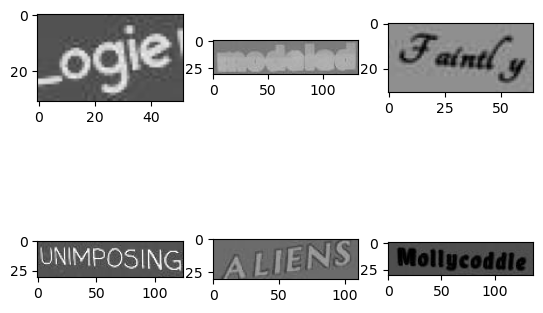

In [18]:
from matplotlib.pyplot import subplots, imshow
case_cnt = 6

# Get wrong cases and listify the strings
hypo = [list(w[1]) for w in prediction['wrong_cases'][:case_cnt]]
truth = [list(w[0]) for w in prediction['wrong_cases'][:case_cnt]]

# Assign indices to every character
hypo_indices = [(0, i, j) for i, s in enumerate(hypo) for j, _ in enumerate(s)]
truth_indices = [(0, i, j) for i, s in enumerate(truth) for j, _ in enumerate(s)]

# Find the longest label's length
hypo_max_len = len(max(hypo, key=len))
truth_max_len = len(max(truth, key=len))

# Flatten
hypo = [c for w in hypo for c in w]
truth = [c for w in truth for c in w]

# Cast to SparseTensor
sp_hypo = tf.sparse.SparseTensor(hypo_indices, hypo, (1, case_cnt, hypo_max_len))
sp_truth = tf.sparse.SparseTensor(truth_indices, truth, (1, case_cnt, truth_max_len))

# Calculate edit distance
edit_dist = tf.edit_distance(sp_hypo, sp_truth, normalize=False)

# Print report
print(f"""Accuracy:\t{prediction['acc']}
Average loss:\t{prediction['loss']}

Wrong cases:
{'-' * (23 + max(hypo_max_len, 12) + max(truth_max_len, 10))}
| {'Ground-truth':{hypo_max_len}} | {'Prediction':{truth_max_len}} | {'Edit distance':1} |
{'-' * (23 + max(hypo_max_len, 12) + max(truth_max_len, 10))}
""", end='')

wrong_case_paths = []
for i in range(case_cnt):
    print(f"| {''.join(prediction['wrong_cases'][i][0]):{max(hypo_max_len, 12)}} | {''.join(prediction['wrong_cases'][i][1]):{max(truth_max_len, 10)}} | {int(edit_dist[0, i]):13} |")
    wrong_case_paths.append(test_dataset.paths[test_dataset.texts.index(prediction['wrong_cases'][i][0])])
print(f"{'-' * (23 + max(hypo_max_len, 12) + max(truth_max_len, 10))}")

# Show images
fig, axes = subplots(2, case_cnt // 2)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(Image.open(wrong_case_paths[i]))

## Q8

As shown above, accuracy is around 0.64, and average loss is around 1.41.

| Ground-truth | Prediction | Edit distance |
| - | - | - |
| Logier | ogier | 1 |
| modeled | modaled | 1 |
| Faintly | Fuinelly | 3 |
| UNIMPOSING | UNMPOSING | 1 |
| aliens | ALIENS | 6 |
| Mollycoddle | Mollyceddle | 1 |

The corresponding images are shown in the subplots above.



## Q9

Though gradient clipping is applied to the training, it does not have obvious difference by experiment. This may occur if no exploding gradient during training.

In general, it can be expected that gradient clipping can stablize the decrease progress of the training loss. It is because the large magnitude gradients are reduced so that the training loss will not jump suddenly.

In terms of the advantages, it can help the model to converge more reliably.

# Clustering

## C8

In [23]:
# Configuration
clustering_config = evaluate_config.copy()
clustering_config['checkpoints_dir'] = 'checkpoints/'

# Dataset
clustering_ds_obj = Synth90kDataset(root_dir=config['data_dir'], mode=DatasetMode.TEST,
                                    img_height=config["img_height"], img_width=config["img_width"])
clustering_ds = clustering_ds_obj.create_tf_dataset(batch_size=clustering_config['eval_batch_size'])

# Get CRNN model
if 'trainer' in locals():
    clustering_CRNN = trainer.model
elif 'new_trainer' in locals():
    clustering_CRNN = new_trainer.model
else:
    step = '010000'
    clustering_CRNN = tf.keras.load_model(f"clustering_config['checkpoints_dir']/model_{step}.weights.h5")

# Inference via CRNN
logits = []

for batch in clustering_ds:
    logits.append(clustering_CRNN.call(batch, training=False))

# Stacking
logits = np.vstack(logits)
logits = np.vstack([logits[i] for i in range(logits.shape[0])])

# Get greedy per-step labels
greedy_labels = np.argmax(tf.nn.softmax(logits), axis=1)
greedy_labels

/usr/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_211
Received: inputs=('Tensor(shape=(256, 32, 100, 1))', 'Tensor(shape=(256, 32))', 'Tensor(shape=(256,))')
  warnings.warn(msg)


array([40,  0,  0, ...,  0,  0, 29], shape=(239616,))

## C9

In [24]:
from sklearn.cluster import KMeans
k = 63

# Standardization
mean = np.mean(logits, axis=0)
std = np.std(logits, axis=0)
logits_std = (logits - mean) / std

# K-means clustering
clustering_model = KMeans(k)
k_mean_labels = clustering_model.fit_predict(logits_std)
k_mean_labels

array([43, 43, 43, ..., 10, 10, 26], shape=(239616,), dtype=int32)

## C10

In [25]:
from sklearn.metrics import silhouette_score

# Calculate the Silhouette Score
sil = silhouette_score(logits_std, k_mean_labels, sample_size=50000)

sil

0.13603587448596954

In [26]:
y_cluster_greedy = np.full((k_mean_labels.shape[0], k+1), k+1, dtype="int32")
y_cluster_greedy[np.arange(k_mean_labels.shape[0]),k_mean_labels] = greedy_labels

cluster_greedy_count = np.sum(y_cluster_greedy.reshape((-1,k+1,1)) == np.arange(k+1).reshape((1,1,-1)), axis=0)[:k, :k]
purity = np.sum(np.max(cluster_greedy_count, axis=1)) / k_mean_labels.shape[0]

float(purity)

0.8248697916666666

## Q10

The Silhouette Score is around 0.14, and the cluster purity is around 0.82.

Silhouette score is a metric to measure the degree of separation among clusters. It is in between [-1, 1]. Larger score means a better separated clustering whereas lower score means a indifferent or even incorrect clustering.

Cluster purity is a metric between [0, 1], which measures the degree of grouping data points with the same label into 1 cluster. Larger score means a more obvious, distinct label in a cluster whereas lower score means a more disorganized cluster.

The low Silhouette score illustrated a poor separation of clusters, but the high cluster purity indicated a reasonable homogeneous grouping in every cluster.

As the cluster purity uses greedy labels inferred by the CRNN model, it can be concluded that the prediction from the CRNN model is similar to that from the K-mean clustering model.

## Q11

(i) \
Softmax argmax decoding only degenerates the probabilities of labels into 1 prediction on 1 data sample. However, the logit space contains a sample probability distribution of labels with all data points, which makes clustering processes in a global way. Besides, this allows clustering to show the confidence / uncertainty of grouping by inspecting the shapes of the distributions of each cluster.

In terms of confusion modes, performing clustering allows investigation on any confusion pattern by looking at the distribution of labels in every cluster. This is not easy if using softmax argmax decoding.

(ii) \
The greedy labels are generated by the CRNN model, which uses the training dataset. Using test dataset can ensure the fairness and unbiasedness when doing clustering and doing inspection afterwards. Moreover, due to this situation, using datasets other training can prevent leakage.